# 04 — Baselines and CNN from scratch

Loads `data/final_dataset.npz` from notebook 03 and trains a small CNN.

**Order in this notebook is deliberate:** baselines first, then the sanity
check, then real training. Each step catches a class of bug that the next step
would otherwise hide.

Carried in from notebooks 01–02:
- Class labels are confounded with framing and field of view
- On the mixed sample, silhouette-only classification reached 0.580 vs a
  majority baseline of 0.262
- These controls must be **recomputed on this exact test set** — see §2

## 1. Setup

In [2]:
import json, time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

# MPS is the Apple Silicon GPU backend. Falls back to CPU if unavailable.
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("torch :", torch.__version__)
print("device:", DEVICE)

torch : 2.13.0
device: mps


In [4]:
d = np.load("data/final_dataset.npz", allow_pickle=True)

X_train, y_train = d["X_train"], d["y_train"]
X_val,   y_val   = d["X_val"],   d["y_val"]
X_test,  y_test  = d["X_test"],  d["y_test"]
CLASSES = [str(c) for c in d["classes"]]

print(f"train {X_train.shape}  val {X_val.shape}  test {X_test.shape}")
print("classes:", CLASSES)
print(f"dtype {X_train.dtype}, range {X_train.min():.2f}-{X_train.max():.2f}")

train (4803, 224, 224)  val (797, 224, 224)  test (886, 224, 224)
classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
dtype float32, range 0.00-1.00


## 2. Baselines on THIS test set

The controls from notebooks 01–02 were computed on a mixed sample of all
7,200 images. The clean test set has a **different class distribution** —
`notumor` lost ~88% of its images to leakage removal. Comparing a model
trained here against a baseline computed there would be apples to oranges.

Recompute both on the actual evaluation set.

In [5]:
print("Test set class distribution:")
for i, cls in enumerate(CLASSES):
    n = int((y_test == i).sum())
    print(f"  {cls:<14} {n:>4}  ({100*n/len(y_test):>5.1f}%)")

maj = np.bincount(y_test).max() / len(y_test)
print(f"\nMajority-class baseline on clean test: {maj:.3f}")
print("(NOT 0.262 — that was the full mixed sample)")

Test set class distribution:
  glioma          314  ( 35.4%)
  meningioma      227  ( 25.6%)
  notumor          47  (  5.3%)
  pituitary       298  ( 33.6%)

Majority-class baseline on clean test: 0.354
(NOT 0.262 — that was the full mixed sample)


In [6]:
# Silhouette control on this exact test set.
# Binarizing destroys all intensity information, leaving only head shape.
# Whatever this scores is reachable without any anatomy — it is the real
# floor for interpreting the CNN.
from sklearn.linear_model import LogisticRegression
import cv2

def silhouette_border(arr):
    a = cv2.resize(arr, (32, 32), interpolation=cv2.INTER_AREA)
    a = (a > 0.1).astype(np.float32)          # arrays are already 0-1
    return np.concatenate([a[:3].ravel(), a[-3:].ravel(),
                           a[3:-3, :3].ravel(), a[3:-3, -3:].ravel()])

Xs_tr = np.stack([silhouette_border(a) for a in X_train])
Xs_te = np.stack([silhouette_border(a) for a in X_test])

shape_clf = LogisticRegression(max_iter=2000).fit(Xs_tr, y_train)
shape_acc = shape_clf.score(Xs_te, y_test)

print(f"{'majority baseline':<28}{maj:.3f}")
print(f"{'silhouette-only control':<28}{shape_acc:.3f}")
print(f"\nReport CNN accuracy against {shape_acc:.3f}, not {maj:.3f}.")

majority baseline           0.354
silhouette-only control     0.484

Report CNN accuracy against 0.484, not 0.354.


## 3. Dataset and augmentation

Augmentation happens **on the fly**, not baked into the cached arrays — it
must be re-randomized every epoch to have any effect.

Train and eval use separate pipelines. Applying augmentation to validation is
a classic bug: it makes val scores noisy and non-comparable across epochs.

In [8]:
from torchvision import transforms
from PIL import Image

with open("data/norm_stats.json") as f:
    stats = json.load(f)
MEAN, STD = stats["mean"], stats["std"]
print(f"normalization: mean={MEAN:.4f} std={STD:.4f}")

train_tf = transforms.Compose([
    transforms.RandomRotation(12),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([MEAN], [STD]),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([MEAN], [STD]),
])


class BrainMRI(Dataset):
    def __init__(self, X, y, transform):
        self.X, self.y, self.transform = X, y, transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        # torchvision transforms expect PIL; arrays are float 0-1, so scale
        # back to uint8 for the conversion.
        img = Image.fromarray((self.X[i] * 255).astype(np.uint8))
        return self.transform(img), int(self.y[i])


BATCH = 32
# num_workers=0 on MPS — multiprocessing workers are unreliable on that
# backend and the speedup is minimal for cached in-memory arrays.
train_ds = BrainMRI(X_train, y_train, train_tf)
val_ds   = BrainMRI(X_val,   y_val,   eval_tf)
test_ds  = BrainMRI(X_test,  y_test,  eval_tf)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

print(f"batches: train {len(train_dl)}, val {len(val_dl)}, test {len(test_dl)}")

normalization: mean=0.2115 std=0.1994
batches: train 150, val 25, test 28


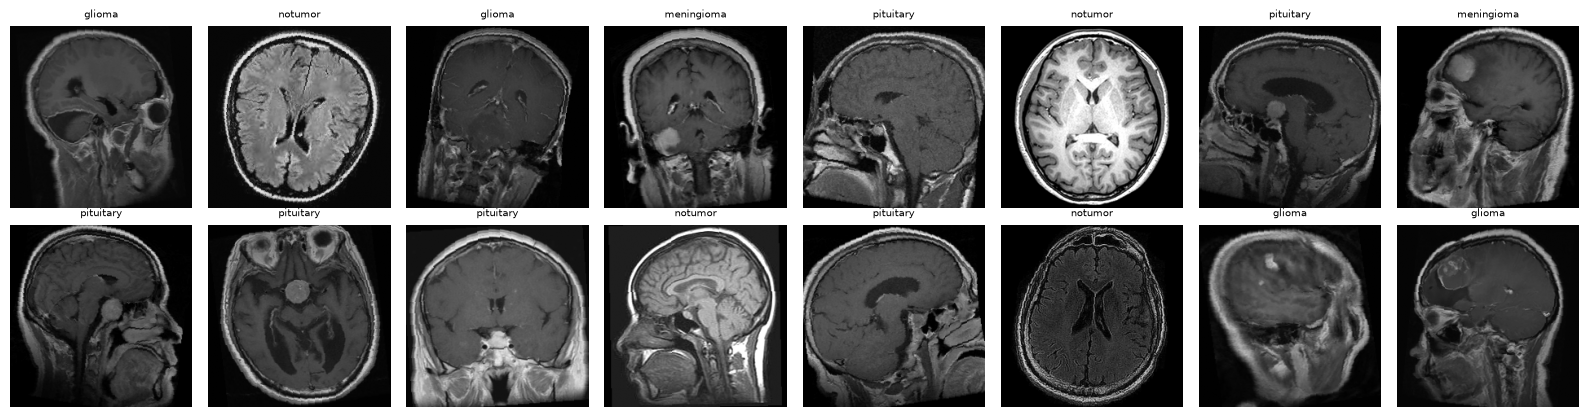

tensor shape: torch.Size([32, 1, 224, 224])


In [10]:
# Look at augmented images before training on them. If any look like
# something a scanner could never produce, dial the augmentation back.
xb, yb = next(iter(train_dl))
fig, axes = plt.subplots(2, 8, figsize=(16, 4.2))
for j, ax in enumerate(axes.ravel()):
    img = xb[j, 0].numpy() * STD + MEAN        # undo normalization to view
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(CLASSES[yb[j]], fontsize=7)
    ax.axis("off")
plt.tight_layout(); plt.show()

print("tensor shape:", xb.shape)   # (B, 1, 224, 224)

## 4. The model

Four conv blocks, each: two 3×3 convolutions with batch norm and ReLU, then
max pooling. Channels double per block (32 → 64 → 128 → 256), spatial size
halves (224 → 112 → 56 → 28 → 14).

Global average pooling instead of flatten + dense: far fewer parameters, and
it makes the model somewhat less sensitive to *where* in the frame a feature
appears — mildly useful given the framing confound.

**Trace the shapes yourself** through the printout below and confirm they
match what you expect. That exercise teaches more about convolution than any
tutorial.

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=4, in_ch=1, width=32, p_drop=0.3):
        super().__init__()

        def block(cin, cout):
            return nn.Sequential(
                # padding=1 with a 3x3 kernel keeps spatial size unchanged,
                # so only the pooling layer changes dimensions.
                nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                # bias=False because BatchNorm has its own shift parameter —
                # a bias here would be redundant.
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        w = width
        self.features = nn.Sequential(
            block(in_ch, w),      # 224 -> 112
            block(w,     w*2),    # 112 -> 56
            block(w*2,   w*4),    # 56  -> 28
            block(w*4,   w*8),    # 28  -> 14
        )
        # GAP collapses each channel's 14x14 map to a single number,
        # giving a 256-vector regardless of input size.
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(p_drop)
        self.fc = nn.Linear(w*8, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.fc(self.drop(x))


model = SmallCNN(n_classes=len(CLASSES)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")

# Shape trace
x = torch.randn(2, 1, 224, 224).to(DEVICE)
for i, blk in enumerate(model.features):
    x = blk(x)
    print(f"  after block {i+1}: {tuple(x.shape)}")

## 5. Sanity check — overfit 16 images

**Run this before any real training.** Take 16 images, turn augmentation off,
and train until the model memorizes them at 100% accuracy.

If it can't, there's a bug — scrambled label mapping, broken normalization,
detached gradients — and no amount of hyperparameter tuning will fix it. Two
minutes here saves days.

In [ ]:
tiny_X, tiny_y = X_train[:16], y_train[:16]
tiny_dl = DataLoader(BrainMRI(tiny_X, tiny_y, eval_tf), batch_size=16)

probe = SmallCNN(n_classes=len(CLASSES)).to(DEVICE)
opt = torch.optim.AdamW(probe.parameters(), lr=3e-3)

probe.train()
for step in range(120):
    for xb, yb in tiny_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = F.cross_entropy(probe(xb), yb)
        loss.backward()
        opt.step()
    if (step + 1) % 30 == 0:
        acc = (probe(xb).argmax(1) == yb).float().mean().item()
        print(f"  step {step+1:>3}  loss {loss.item():.4f}  acc {acc:.3f}")

print("\nExpect acc 1.000 by the end. If not, STOP and debug.")

## 6. Training loop

In [ ]:
from sklearn.metrics import f1_score

def run_epoch(model, loader, optimizer=None):
    """One pass over a loader. Pass optimizer=None to evaluate."""
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss, preds, trues = 0.0, [], []
    # no_grad during eval saves memory and time — no graph is built.
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = F.cross_entropy(out, yb)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            preds.append(out.argmax(1).cpu())
            trues.append(yb.cpu())

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    return (total_loss / len(trues),
            (preds == trues).mean(),
            f1_score(trues, preds, average="macro"))

In [ ]:
EPOCHS = 40
PATIENCE = 10        # stop if val macro-F1 hasn't improved in this many epochs

model = SmallCNN(n_classes=len(CLASSES)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = defaultdict(list)
best_f1, best_epoch, since_improve = 0.0, 0, 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_dl, optimizer)
    va_loss, va_acc, va_f1 = run_epoch(model, val_dl)
    scheduler.step()

    for k, v in [("tr_loss", tr_loss), ("va_loss", va_loss),
                 ("tr_acc", tr_acc), ("va_acc", va_acc),
                 ("tr_f1", tr_f1), ("va_f1", va_f1)]:
        history[k].append(v)

    # Checkpoint on best VALIDATION macro-F1, not the last epoch and not
    # accuracy — macro-F1 doesn't let a large class mask failure on a
    # small one, which matters given the skewed val distribution.
    flag = ""
    if va_f1 > best_f1:
        best_f1, best_epoch, since_improve = va_f1, epoch, 0
        torch.save(model.state_dict(), "checkpoints/best.pt")
        flag = "  <- best"
    else:
        since_improve += 1

    print(f"ep {epoch:>2}  tr_loss {tr_loss:.3f} va_loss {va_loss:.3f}  "
          f"tr_acc {tr_acc:.3f} va_acc {va_acc:.3f}  va_f1 {va_f1:.3f}  "
          f"({time.time()-t0:.0f}s){flag}")

    if since_improve >= PATIENCE:
        print(f"\nEarly stop — no improvement in {PATIENCE} epochs.")
        break

print(f"\nBest val macro-F1 {best_f1:.3f} at epoch {best_epoch}")

Create the checkpoint directory first if the cell above errors:
`Path("checkpoints").mkdir(exist_ok=True)`

## 7. Curves

The gap between train and val is the most informative thing here.

- Both falling, small gap → healthy
- Train falling, val rising → overfitting; more augmentation or stop earlier
- Both flat and high → underfitting; more capacity or higher learning rate
- Val jagged → learning rate too high, or batch size too small

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (a, b, name) in zip(axes, [("tr_loss", "va_loss", "loss"),
                                   ("tr_acc", "va_acc", "accuracy"),
                                   ("tr_f1", "va_f1", "macro F1")]):
    ax.plot(history[a], label="train")
    ax.plot(history[b], label="val")
    ax.set_xlabel("epoch"); ax.set_title(name); ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

# Reference lines: the model must clear the shape control to mean anything.
axes[1].axhline(shape_acc, ls="--", c="red", lw=1)
axes[1].axhline(maj, ls=":", c="gray", lw=1)
plt.tight_layout(); plt.show()
print(f"red dashed = silhouette control ({shape_acc:.3f})")
print(f"gray dotted = majority baseline ({maj:.3f})")

## 8. Log the run

One row per experiment. You will do 15–30 runs and will not remember which
was which.

In [ ]:
import csv
from pathlib import Path

Path("results").mkdir(exist_ok=True)
log_path = Path("results/experiments.csv")

row = {
    "model": "SmallCNN w32",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "batch": BATCH,
    "augment": "rot12+hflip+jitter",
    "epochs_run": len(history["tr_loss"]),
    "best_epoch": best_epoch,
    "best_val_f1": round(best_f1, 4),
    "best_val_acc": round(max(history["va_acc"]), 4),
    "shape_control": round(shape_acc, 4),
    "notes": "",
}

write_header = not log_path.exists()
with open(log_path, "a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(row))
    if write_header:
        w.writeheader()
    w.writerow(row)

print("logged:", row)

## Next

Do **not** touch the test set yet. Next is `05_transfer_learning.ipynb` —
ResNet18 pretrained on ImageNet, with the two-stage freeze/fine-tune schedule.
Pick the final model on validation, then evaluate on test exactly once.